In [52]:
try:
    get_ipython().run_line_magic('load_ext' , 'autoreload')
    get_ipython().run_line_magic('autoreload', 2)
except:
    pass

import logging
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.ndimage import gaussian_filter
from tifffile.tifffile import imwrite

import caiman as cm
from caiman.utils.visualization import nb_view_patches3d
import caiman.source_extraction.cnmf as cnmf
from caiman.paths import caiman_datadir

import bokeh.plotting as bpl
bpl.output_notebook()

logging.basicConfig(format=
                          "%(relativeCreated)12d [%(filename)s:%(funcName)20s():%(lineno)s] [%(process)d] %(message)s",
                    # filename="/tmp/caiman.log",
                    level=logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Loading BokehJS ...

In [72]:
fname_load = "/Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/20230627_2_hires_.tif"
fname = "/Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/20230627_2_hires_new_.tif"
Y = cm.load(fname_load)
Y = Y.reshape(80, -1, 140, 256)
# Y = Y[:,:-51,:,:] #crop flyback frames, only do this on unregistered hires stacks (registration in matlab crops it)
Y = np.transpose(Y, (0, 3, 2, 1))
imwrite(fname, Y) #write as t x y z
dims = Y.shape
dims = dims[1:]

#%% start a cluster for parallel processing (if a cluster already exists it will be closed and a new session will be opened)
if 'dview' in locals():
    cm.stop_server(dview=dview)
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='local', n_processes=None, single_thread=False)

    # motion correction parameters
opts_dict = {'fnames': fname,
            'strides': (24, 24, 6),    # start a new patch for pw-rigid motion correction every x pixels
            'overlaps': (12, 12, 2),   # overlap between pathes (size of patch strides+overlaps)
            'max_shifts': (4, 4, 2),   # maximum allowed rigid shifts (in pixels)
            'max_deviation_rigid': 5,  # maximum shifts deviation allowed for patch with respect to rigid shifts
            'pw_rigid': False,         # flag for performing non-rigid motion correction
            'is3D': True}

opts = cnmf.params.CNMFParams(params_dict=opts_dict)


mc = cm.motion_correction.MotionCorrect(fname, dview=dview, **opts.get_group('motion'))
mc.motion_correct(save_movie=True);

fname_new = cm.save_memmap(mc.mmap_file, base_name='memmap_', order='C',
                           border_to_0=0, dview=dview) # exclude borders

# now load the file
Yr, dims, T = cm.load_memmap(fname_new)
images2 = np.reshape(Yr.T, [T] + list(dims), order='F') 

cm.stop_server(dview=dview)
breakpoint()
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='local', n_processes=None, single_thread=False)


    18280026 [params.py:   check_consistency():944] [91497] is3D=True, hence setting key indices automatically to (slice(None, None, None), slice(None, None, None), slice(None, None, None))
2023-07-04 19:56:21.146270: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/20230627_2_hires_new__rig__d1_256_d2_140_d3_164_order_F_frames_80.mmap
Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_164_order_C_frames_80.mmap


In [77]:
type(Yr)

numpy.memmap

In [55]:
fname_load = "/Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/20230627_2_hires_registered_.tif"
fname = "/Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/20230627_2_hires_registered_new_.tif"
Y = cm.load(fname_load)
Y = Y.reshape(80, -1, 140, 256)
# Y = Y[:,:-51,:,:] #crop flyback frames, only do this on unregistered hires stacks (registration in matlab crops it)
Y = np.transpose(Y, (0, 3, 2, 1))
imwrite(fname, Y) #write as t x y z
dims = Y.shape
dims = dims[1:]

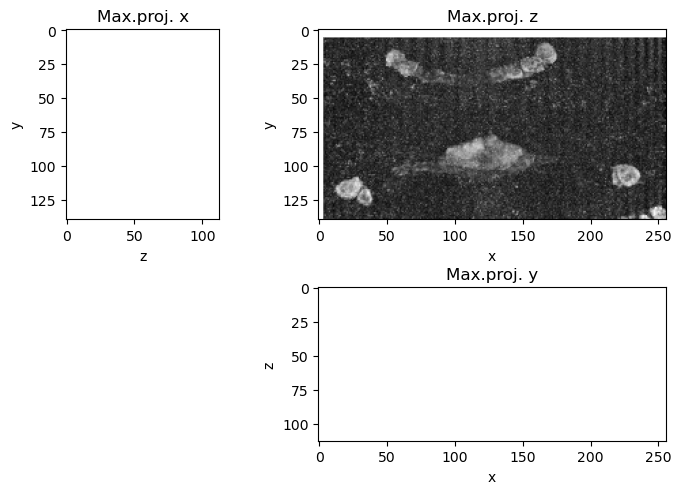

In [56]:
Y = cm.load(fname)
Cn = cm.local_correlations(Y, swap_dim=False)
d1, d2, d3 = dims
x, y = (int(1.2 * (d1 + d3)), int(1.2 * (d2 + d3)))
scale = 6/x
fig = plt.figure(figsize=(scale*x, scale*y))
axz = fig.add_axes([1-d1/x, 1-d2/y, d1/x, d2/y])
plt.imshow(Cn.max(2).T, cmap='gray')
plt.title('Max.proj. z')
plt.xlabel('x')
plt.ylabel('y')
axy = fig.add_axes([0, 1-d2/y, d3/x, d2/y])
plt.imshow(Cn.max(0), cmap='gray')
plt.title('Max.proj. x')
plt.xlabel('z')
plt.ylabel('y')
axx = fig.add_axes([1-d1/x, 0, d1/x, d3/y])
plt.imshow(Cn.max(1).T, cmap='gray')
plt.title('Max.proj. y')
plt.xlabel('x')
plt.ylabel('z');
plt.show()

In [57]:
# tmp = np.transpose(Y, (0, 3, 2, 1))
# tmp[:,20,:,:].play(magnification=4) #play as t z y x


In [58]:
#%% start a cluster for parallel processing (if a cluster already exists it will be closed and a new session will be opened)
if 'dview' in locals():
    cm.stop_server(dview=dview)
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='local', n_processes=None, single_thread=False)

In [59]:
# motion correction parameters
opts_dict = {'fnames': fname,
            'strides': (24, 24, 6),    # start a new patch for pw-rigid motion correction every x pixels
            'overlaps': (12, 12, 2),   # overlap between pathes (size of patch strides+overlaps)
            'max_shifts': (4, 4, 2),   # maximum allowed rigid shifts (in pixels)
            'max_deviation_rigid': 5,  # maximum shifts deviation allowed for patch with respect to rigid shifts
            'pw_rigid': False,         # flag for performing non-rigid motion correction
            'is3D': True}

opts = cnmf.params.CNMFParams(params_dict=opts_dict)

     5225380 [params.py:   check_consistency():944] [91497] is3D=True, hence setting key indices automatically to (slice(None, None, None), slice(None, None, None), slice(None, None, None))


In [60]:
# first we create a motion correction object with the parameters specified
mc = cm.motion_correction.MotionCorrect(fname, dview=dview, **opts.get_group('motion'))
# note that the file is not loaded in memory

In [61]:
%%capture
#%% Run motion correction using NoRMCorre
mc.motion_correct(save_movie=True);

2023-07-04 16:18:45.863465: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Text(0, 0.5, 'pixels')

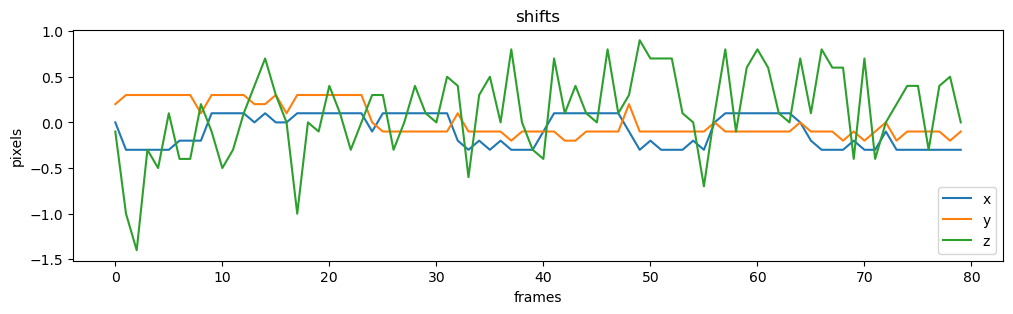

In [62]:
plt.figure(figsize=(12,3))
plt.subplot(1,1,1)
for k in (0,1,2):
    plt.plot(np.array(mc.shifts_rig)[:,k], label=('x','y','z')[k])
plt.legend()
plt.title('shifts')
plt.xlabel('frames')
plt.ylabel('pixels')

In [63]:
# memory map the file in order 'C'
fname_new = cm.save_memmap(mc.mmap_file, base_name='memmap_', order='C',
                           border_to_0=0, dview=dview) # exclude borders

# now load the file
Yr, dims, T = cm.load_memmap(fname_new)
images = np.reshape(Yr.T, [T] + list(dims), order='F') 
    #load frames in python format (T x X x Y)

Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/20230627_2_hires_registered_new__rig__d1_256_d2_140_d3_113_order_F_frames_80.mmap
Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_113_order_C_frames_80.mmap


In [71]:
np.max(images)

255.80927

In [42]:
#%% restart cluster to clean up memory
cm.stop_server(dview=dview)
breakpoint()
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='local', n_processes=None, single_thread=False)

In [43]:

p = 0                   # order of the autoregressive system - 0 from carl's code
merge_thresh = 0.8
gSig = [3, 3, 3]  # gSig = [3,3]            # radius (half-size) of average neurons (in pixels)
nb = 1                  # temporal global background components - TUNE

do_patches = True      # flag for processing in patches or not - turn on or off - Not used in Matlab
if do_patches:          # PROCESS IN PATCHES AND THEN COMBINE
    rf = 20             # half size of each patch
    stride = 12          # overlap between patches
    p_patch = p
    nb_patch = nb
    k = 3               # number of components in each patch
else:                   # PROCESS THE WHOLE FOV AT ONCE
    rf = None           # setting these parameters to None
    stride = None       # will run CNMF on the whole FOV
    ###
    k = 70              # number of neurons expected (in the whole FOV) - 40 from Carl's Code, seems to be too many

###
fr = 0.6193  #9.8465 frame period so 1000 / (9.8465 *(113+51)) # approximate frame rate of data - CONFIRMED FPS
decay_time = .4         # length of transient - CONFIRMED APPROPRIATE FOR OUR INDICATOR GCaMP6f
dxy = [1.33155792277, 1.33155792277, 1.33155792277] #for .751 um pixels # pixels per micron 
#dims_in_blah = [140, 256]       # dimensions of the FOV in pixels - CONFIRMED

tsub = 1                # temporal downsampling
ssub = 1               # spatial downsampling

method_init = 'greedy_roi' #python Caiman defaults to greedy_roi, carl's code uses sparse_nmf, but sparse_nmf runs MUCH slower
sigma_smooth_snmf = (.5,.5,.5)
perc_baseline_snmf = 50

se = np.ones((3,)*len(dims), dtype=np.uint8)  #se = np.ones((3,3,1), dtype=np.uint8)
update_background_components = True   #use this??

fudge_factor = 0.96        # (default is 0.96; Carl's value = 1) -- bias correction factor for discrete time constants
ITER = 2                # (default is 2; Carl's value=5) -- block coordinate descent iterations
bas_nonneg = False #True

min_SNR = 0      # accept components with that peak-SNR or higher (if above this, acept)
SNR_lowest = 0         # minimum SNR for accepted components (if below this, reject)
rval_lowest = 0  # 0.6  # space correlation threshold (if above this, accept)
rval_thr = 0  # 0.6  # space correlation threshold (if above this, accept)
use_cnn = False      # use the CNN classifier affects if 2 below params are used
min_cnn_thr = 0  # if cnn classifier predicts below this value, reject
cnn_lowest = 0.1   # neurons with cnn probability lower than this value are rejected

cnm = cnmf.CNMF(n_processes, dview=dview, gSig=gSig)

cnm.params.set('data', {
                    #'fnames': fnames,
                   'fr': fr,
                   'decay_time': decay_time,
                   'dxy': dxy
                            })

cnm.params.set('patch', {
                    'rf': rf,
                    'stride': stride,
                    'p_patch': p_patch,
                    'nb_patch': nb_patch,
                     #'n_processes': n_processes,
                            })

cnm.params.set('preprocess', {
                    'p': p
                            })

cnm.params.set('init', {
                    'K': k,     #little K here in 'init', big K if passed to CNMF class        # declared above in patch params
                    #'gSig': gSig, #for some reason have to pass this to cnmf
                    'tsub': tsub,
                    'ssub': ssub,
                    'gSig': gSig,
                    'nb': nb, #decleared in temporal
                    'method_init': method_init,
                    'sigma_smooth_snmf': sigma_smooth_snmf,
                    'perc_baseline_snmf': perc_baseline_snmf
                            })

cnm.params.set('spatial', {
                    'nb': nb,  #can i make this diff from temporal? 
                    'se': se, 
                            })

cnm.params.set('temporal', {
                    'p': p,
                    #'fudge_factor': fudge_factor,
                    #'ITER': ITER,
                    'nb': nb,  #can i make this diff from spatial? 
                    'bas_nonneg': bas_nonneg,
                            })

cnm.params.set('merging', {
                    'merge_thr': merge_thresh #if you're passing to subdict 'merging' keyword is merge_thr, if passing to CNMF params class it's merge_thresh
                            })

cnm.params.set('quality', {
                    'min_SNR': min_SNR,
                    'SNR_lowest': SNR_lowest,
                    'rval_lowest': rval_lowest,
                    'rval_thr': rval_thr,
                    'use_cnn': use_cnn,
                    'min_cnn_thr': min_cnn_thr,
                    'cnn_lowest': cnn_lowest
                            })


cnm = cnm.fit(images)



2023-07-04 15:39:38.147714: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-04 15:39:38.147849: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-04 15:39:38.147893: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorF

Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_113_order_C_frames_80.mmap
Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_113_order_C_frames_80.mmap
Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_113_order_C_frames_80.mmap
Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_113_order_C_frames_80.mmap
Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_113_order_C_frames_80.mmap
Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_113_order_C_frames_80.mmap
Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_

/Users/wienecke/mambaforge/envs/caiman/lib/python3.10/site-packages/scipy/ndimage/_measurements.py:1535: RuntimeWarning: invalid value encountered in scalar divide
  results = [sum(input * grids[dir].astype(float), labels, index) / normalizer


Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_113_order_C_frames_80.mmap


/Users/wienecke/mambaforge/envs/caiman/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  warnings.warn('nperseg = {0:d} is greater than input length '
/Users/wienecke/mambaforge/envs/caiman/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  warnings.warn('nperseg = {0:d} is greater than input length '
/Users/wienecke/mambaforge/envs/caiman/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  warnings.warn('nperseg = {0:d} is greater than input length '
/Users/wienecke/mambaforge/envs/caiman/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  warnings.warn('nperseg = {0:d} is greater than input length '
/Use

...

Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_113_order_C_frames_80.mmap


/Users/wienecke/mambaforge/envs/caiman/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  warnings.warn('nperseg = {0:d} is greater than input length '


Decode mmap filename /Users/wienecke/Documents/ambrose/leprechaunMat/20230627-2_D05_syt7f_018_syt7f/memmap_d1_256_d2_140_d3_113_order_C_frames_80.mmap


/Users/wienecke/mambaforge/envs/caiman/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  warnings.warn('nperseg = {0:d} is greater than input length '
/Users/wienecke/mambaforge/envs/caiman/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  warnings.warn('nperseg = {0:d} is greater than input length '
/Users/wienecke/mambaforge/envs/caiman/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  warnings.warn('nperseg = {0:d} is greater than input length '
/Users/wienecke/mambaforge/envs/caiman/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  warnings.warn('nperseg = {0:d} is greater than input length '


type: index 3 is out of bounds for axis 0 with size 3

In [21]:
cnm.estimates.nb_view_components_3d(image_type='mean', dims=dims, axis=2)
print(('Number of components:' + str(cnm.estimates.A.shape[-1])))

In [22]:
cnm.estimates.nb_view_components_3d(image_type='corr', dims=dims, Yr=Yr, denoised_color='red', max_projection=True);

type: object dtype is not supported by sparse matrices

In [ ]:

cnm.estimates.evaluate_components(images, cnm.params, dview=dview)

print(('Keeping ' + str(len(cnm.estimates.idx_components)) +
       ' and discarding  ' + str(len(cnm.estimates.idx_components_bad))))

In [ ]:
cnm.estimates.nb_view_components_3d(image_type='mean', dims=dims, axis=2);

In [ ]:
cnm.estimates.nb_view_components_3d(image_type='corr', dims=dims, Yr=Yr, denoised_color='red', max_projection=True);

In [ ]:
%%capture
cnm.params.set('temporal', {'p': p})
cnm2 = cnm.refit(images)

In [ ]:
cnm2.estimates.nb_view_components_3d(image_type='mean', dims=dims, axis=2);

In [ ]:
cnm2.estimates.nb_view_components_3d(image_type='corr', dims=dims, Yr=Yr, denoised_color='red', max_projection=True);

In [ ]:
# STOP CLUSTER
cm.stop_server(dview=dview)